# Planteamiento

Predicción de Calidad del Vino (Core)


**Objetivo**

Utilizar técnicas de clasificación aprendidas hasta el momento para predecir la calidad del vino basándose en características físico-químicas. Este ejercicio permitirá aplicar conceptos como la selección de características, preprocesamiento de datos, entrenamiento y evaluación de modelos de clasificación, y análisis de resultados mediante métricas y visualizaciones.

**Dataset:** Wine Quality Dataset



Descripción del Dataset: Este conjunto de datos contiene información sobre distintas características físico-químicas de muestras de vino tinto y su calidad asociada. Las características incluyen acidez fija, acidez volátil, ácido cítrico, azúcar residual, cloruros, dióxido de azufre libre, dióxido de azufre total, densidad, pH, sulfatos y alcohol. La calidad del vino está clasificada en una escala del 0 al 10.



**Instrucciones**

1. Carga y Exploración de Datos:

* Cargar el dataset y revisar su estructura básica.
* Describir las variables y su distribución.
* Identificar y tratar valores nulos y outliers.

2. Preprocesamiento de Datos:

* Seleccionar características importantes para la clasificación.
* Transformar variables categóricas en variables numéricas si es necesario.
* Dividir los datos en conjuntos de entrenamiento y prueba.
* Escalar las características.

3. Entrenamiento de Modelos de Clasificación:

* Entrenar al menos tres modelos de clasificación diferentes (por ejemplo, KNN, RandomForest, y Regresión Logística).
* Utilizar validación cruzada para seleccionar los mejores hiperparámetros.

4. Evaluación de Modelos:

* Evaluar los modelos utilizando métricas como exactitud, precisión, recall, F1-Score y matriz de confusión.
* Generar un informe de clasificación para cada modelo.
* Crear y visualizar la curva ROC y calcular el AUC para el mejor modelo.

5. Análisis y Comparación de Resultados:

* Comparar el rendimiento de los diferentes modelos.
* Discutir cuál modelo ofrece el mejor rendimiento y por qué.
* Identificar las fortalezas y debilidades de cada enfoque en este contexto.

6. Repositorio en GitHub:

* Crear un repositorio en GitHub con el código y los resultados del análisis.
* Crear un tag de liberación con una breve descripción de la versión final del proyecto.

**Adicional**

- Añadir un archivo README.md en el repositorio de GitHub que explique el propósito del proyecto, las técnicas utilizadas y cómo ejecutar el código.
- Incluir una presentación o informe detallado en formato PDF con todos los hallazgos y conclusiones del análisis.

**Nota:** Asegúrate de documentar cada paso del proceso, incluyendo la justificación de las decisiones tomadas durante el preprocesamiento, la selección de modelos y la evaluación de los resultados. Esto proporcionará una visión completa y estructurada del trabajo realizado.

# Respuesta

## 1.- Carga y Exploración de Datos:

* Cargar el dataset y revisar su estructura básica.
* Describir las variables y su distribución.
* Identificar y tratar valores nulos y outliers.


In [28]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets] - no necesario en Colab
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "WineQT.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "yasserh/wine-quality-dataset",
  file_path
)

df.sample(n=5)

Using Colab cache for faster access to the 'wine-quality-dataset' dataset.


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
258,12.5,0.46,0.63,2.0,0.071,6.0,15.0,0.99880,2.99,0.87,10.2,5,363
963,6.1,0.34,0.25,1.8,0.084,4.0,28.0,0.99464,3.36,0.44,10.1,5,1356
809,7.0,0.22,0.30,1.8,0.065,16.0,20.0,0.99672,3.61,0.82,10.0,6,1143
100,5.8,0.68,0.02,1.8,0.087,21.0,94.0,0.99440,3.54,0.52,10.0,5,146
766,7.9,0.19,0.42,1.6,0.057,18.0,30.0,0.99400,3.29,0.69,11.2,6,1087


### Realizar una exploración inicial para entender la estructura del dataset.


In [29]:
# Obtener información sobre el DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


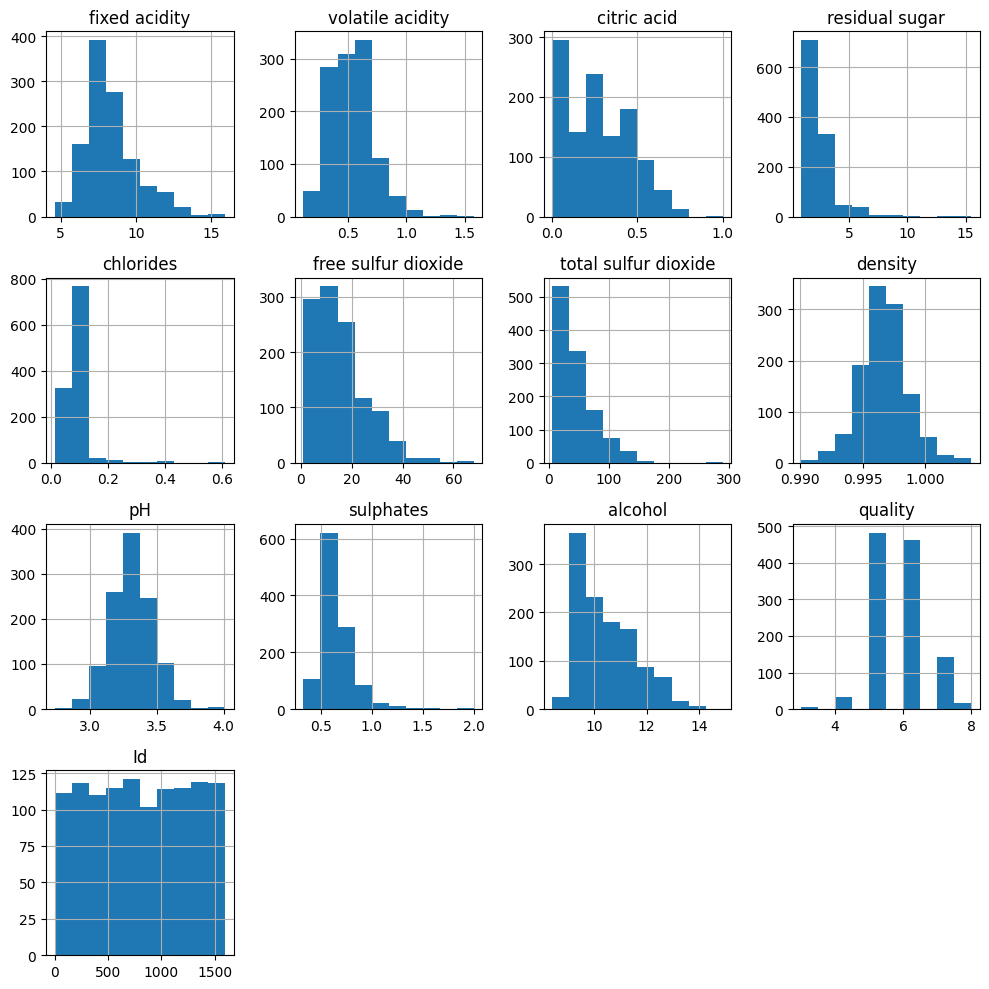

In [30]:
# resumo en un solo coando las distribuciones de todas las variables
import matplotlib.pyplot as plt
df.hist(figsize=(10, 10))
plt.tight_layout()
plt.show()

Las variables density y pH tienen una distribución normal, el resto no

In [31]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [32]:
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595
1142,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,1597


### Identificar valores faltantes, duplicados y outliers.

In [33]:
# reviso los nulos por columna
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [34]:
for c in df.columns:
    print()
    print(f'{c}: {df[c].duplicated().sum()}')


fixed acidity: 1052

volatile acidity: 1008

citric acid: 1066

residual sugar: 1063

chlorides: 1012

free sulfur dioxide: 1090

total sulfur dioxide: 1005

density: 755

pH: 1056

sulphates: 1054

alcohol: 1082

quality: 1137

Id: 0


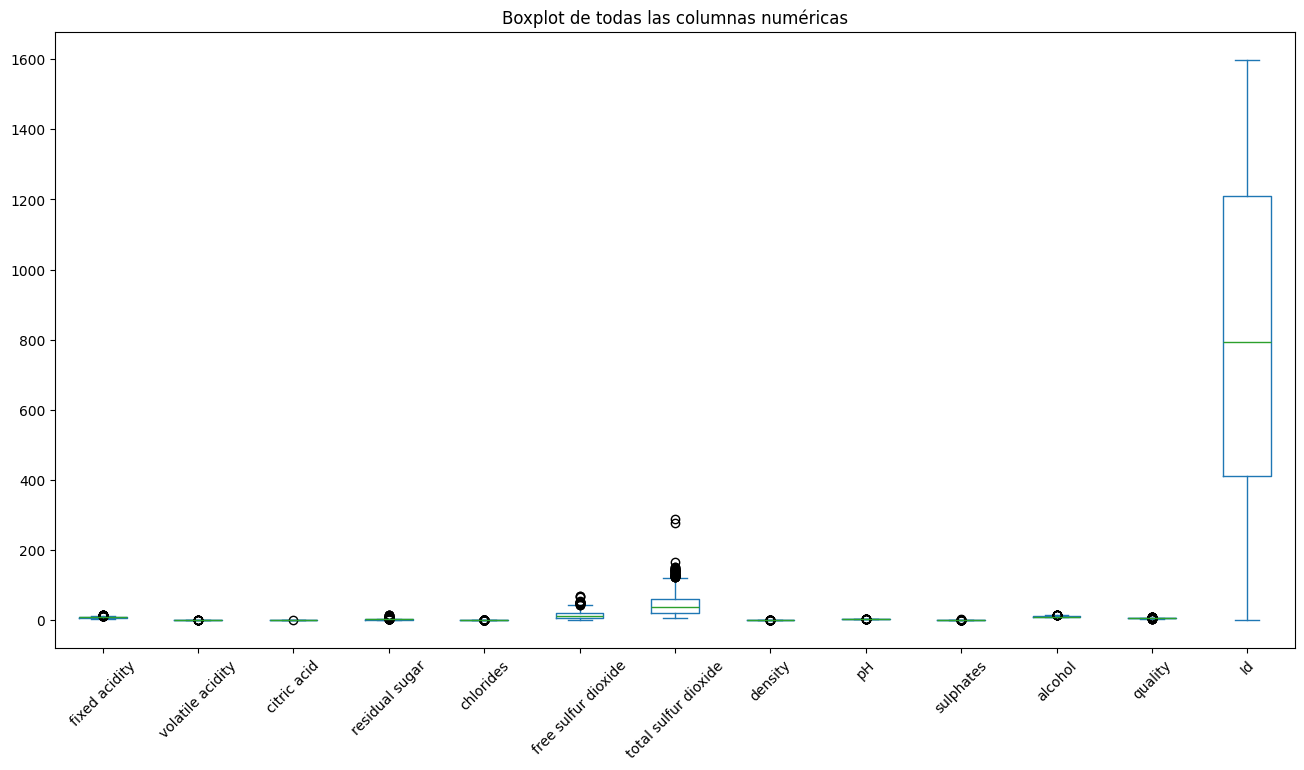

In [35]:
import matplotlib.pyplot as plt

# Boxplot
df[df.select_dtypes(include='number').columns].plot(kind='box', figsize=(16, 8))
plt.xticks(rotation=45)
plt.title('Boxplot de todas las columnas numéricas')
plt.show()

Existen valores atipicos, principalmente en "total sulfur dioxide" y "free sulfur dioxide"

### Eliminar duplicados.

In [36]:
df.drop_duplicates(inplace=True)

In [37]:
df.duplicated().sum()

np.int64(0)

In [38]:
df.dtypes

,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


In [39]:
df.dtypes

,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


In [40]:
df.describe(include="all")

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [41]:
df.dtypes

,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


In [42]:
# Revisa los valores unicos por columna, me permite reconocer que datos contiene cada columna
for c in df.columns:
    print()
    print(f'{c}: {df[c].nunique()}')
    print(f'{c}: {df[c].unique()}')



fixed acidity: 91
fixed acidity: [ 7.4  7.8 11.2  7.9  7.3  6.7  5.6  8.5  7.6  6.9  6.3  7.1  8.3  5.2
  8.1  8.8  7.5  4.6  7.7  6.6  8.6 10.2  7.   7.2  8.   6.8  6.2  9.3
  5.   8.4 10.1  9.4  8.2  5.8  9.2  8.9  6.4 11.5  9.6 12.8  9.7  8.7
 12.  15.  10.8 11.1 10.  12.5 10.3 11.4  9.9 11.6 10.4 13.3 10.6  9.
  9.8 13.4 11.9 10.9 13.8  9.1 13.5  6.1 10.5 12.6 13.7  9.5 12.2 12.3
 15.6  5.3 11.3 13.   6.5 10.7 12.9 14.3 12.4 15.5 12.7 13.2 15.9  5.1
 11.8  4.9  5.9 11.7  5.4  5.7  6. ]

volatile acidity: 135
volatile acidity: [0.7   0.88  0.76  0.28  0.66  0.6   0.65  0.58  0.615 0.61  0.32  0.39
 0.43  0.49  0.4   0.41  0.71  0.645 0.675 0.655 0.38  0.45  0.52  0.935
 0.5   0.51  0.42  0.59  0.69  0.735 0.725 0.705 0.785 0.75  0.625 0.3
 0.55  0.62  1.02  0.775 0.9   0.545 0.575 0.63  0.56  0.31  0.54  1.07
 0.695 1.33  0.745 1.04  0.415 0.34  0.67  0.68  0.33  0.95  0.53  0.64
 0.885 0.805 0.73  0.37  1.09  0.44  0.57  0.48  1.    0.635 0.21  0.35
 0.975 0.87  0.18  0.26  0.27  

## 2.- Preprocesamiento de Datos:

* Seleccionar características importantes para la clasificación.
* Transformar variables categóricas en variables numéricas si es necesario.
* Dividir los datos en conjuntos de entrenamiento y prueba.
* Escalar las características.



In [43]:
correlacion = df.corr(numeric_only=True)
correlacion

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
fixed acidity,1.000000,-0.250728,0.673157,0.171831,0.107889,-0.164831,-0.110628,0.681501,-0.685163,0.174592,-0.075055,0.121970,-0.275826
volatile acidity,-0.250728,1.000000,-0.544187,-0.005751,0.056336,-0.001962,0.077748,0.016512,0.221492,-0.276079,-0.203909,-0.407394,-0.007892
citric acid,0.673157,-0.544187,1.000000,0.175815,0.245312,-0.057589,0.036871,0.375243,-0.546339,0.331232,0.106250,0.240821,-0.139011
residual sugar,0.171831,-0.005751,0.175815,1.000000,0.070863,0.165339,0.190790,0.380147,-0.116959,0.017475,0.058421,0.022002,-0.046344
chlorides,0.107889,0.056336,0.245312,0.070863,1.000000,0.015280,0.048163,0.208901,-0.277759,0.374784,-0.229917,-0.124085,-0.088099
free sulfur dioxide,-0.164831,-0.001962,-0.057589,0.165339,0.015280,1.000000,0.661093,-0.054150,0.072804,0.034445,-0.047095,-0.063260,0.095268
total sulfur dioxide,-0.110628,0.077748,0.036871,0.190790,0.048163,0.661093,1.000000,0.050175,-0.059126,0.026894,-0.188165,-0.183339,-0.107389
density,0.681501,0.016512,0.375243,0.380147,0.208901,-0.054150,0.050175,1.000000,-0.352775,0.143139,-0.494727,-0.175208,-0.363926
pH,-0.685163,0.221492,-0.546339,-0.116959,-0.277759,0.072804,-0.059126,-0.352775,1.000000,-0.185499,0.225322,-0.052453,0.132904
sulphates,0.174592,-0.276079,0.331232,0.017475,0.374784,0.034445,0.026894,0.143139,-0.185499,1.000000,0.094421,0.257710,-0.103954


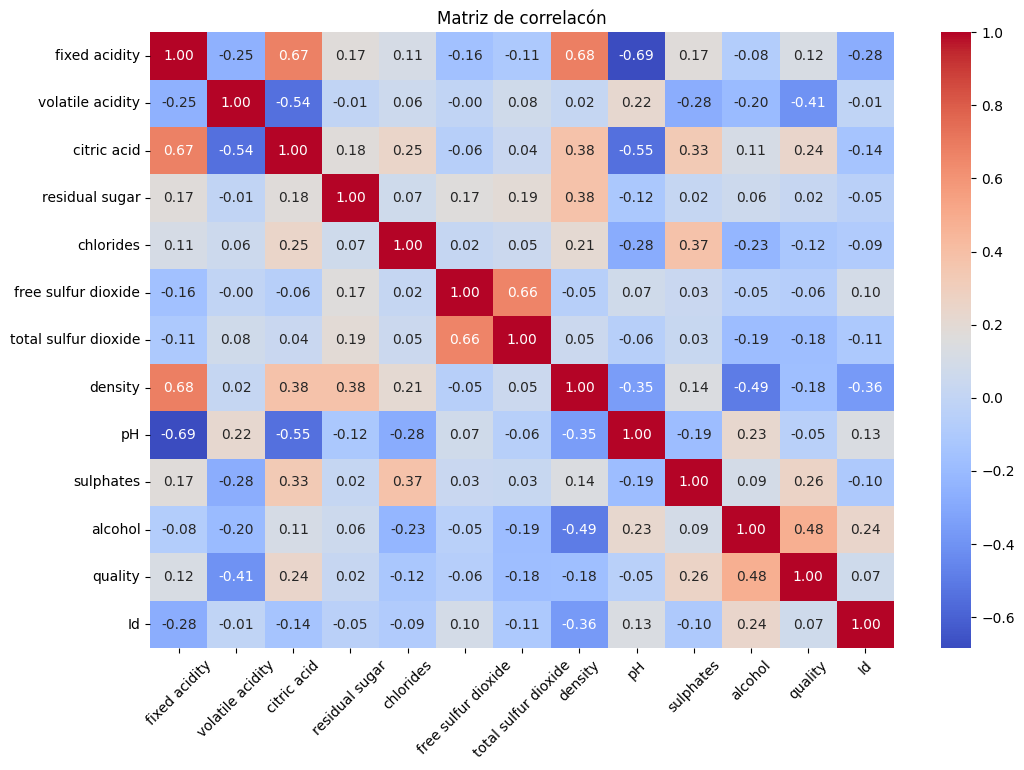

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# grafico heatmap de correlación
plt.figure(figsize=(12, 8)) # Set size before plotting
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f")
plt.xticks(rotation=45)
plt.title("Matriz de correlacón")
plt.show()

observo muy poca correlación entre las variables, existe correlación negativa entre "fixed acidity" y "pH"

### Transformar variables categóricas en variables numéricas si es necesario.

para este conjunto de datso no existe variables categoricas por lo que se omite.

### Dividir los datos en conjuntos de entrenamiento y prueba.

In [45]:
df1 = df.copy()

In [46]:
df1=df1.drop(columns=['Id'])

In [47]:
X = df1.drop(columns=['quality']) # El resto Exepto variable objetivo

In [48]:
y = df1['quality'] # Variable objetivo

In [49]:
from sklearn.model_selection import train_test_split

#  Dividir en train/test correctamente
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 20% para test, 80% para train
    random_state=42,         # ← MUY IMPORTANTE: fija la aleatoriedad para que el resultado sea reproducible
    stratify=y
)

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}, y_test: {y_test.shape}')
print(f'Suma OK: {len(X_train) + len(X_test) == len(X)}')

X_train: (914, 11), X_test: (229, 11)
y_train: (914,), y_test: (229,)
Suma OK: True


### Escalar las características.

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.compose import make_column_transformer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

In [51]:
# Indico columnas a mano
cols_norm = ['density', 'pH']
cols_nonorm = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'sulphates', 'alcohol']


preprocesador = make_column_transformer(
    (StandardScaler(),  cols_norm),
    (MinMaxScaler(),   cols_nonorm),
    remainder='drop'   # qué hacer con columnas no listadas
)
preprocesador

ColumnTransformer(transformers=[('standardscaler', StandardScaler(),
                                 ['density', 'pH']),
                                ('minmaxscaler', MinMaxScaler(),
                                 ['fixed acidity', 'volatile acidity',
                                  'citric acid', 'residual sugar', 'chlorides',
                                  'free sulfur dioxide', 'total sulfur dioxide',
                                  'sulphates', 'alcohol'])])

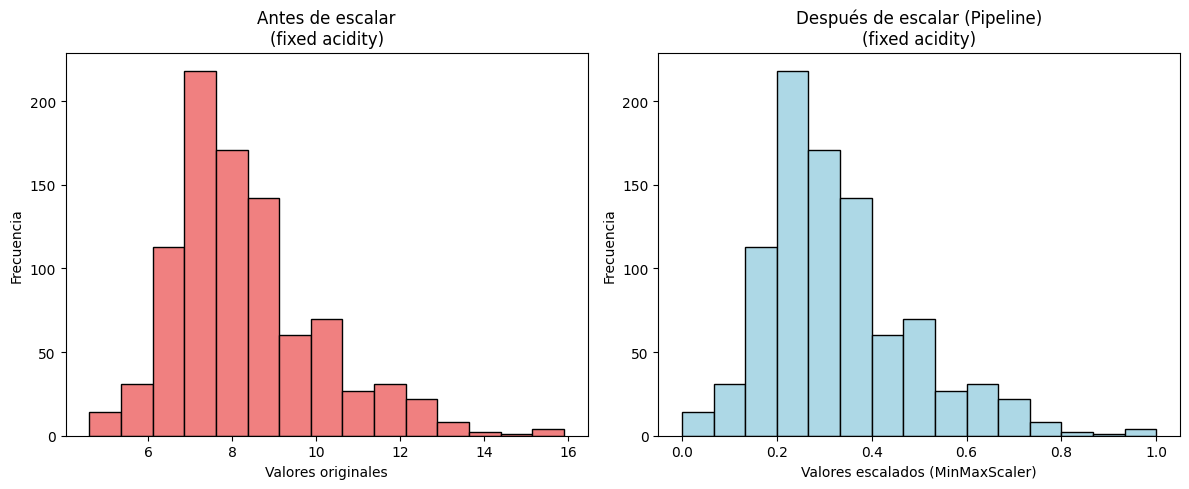

In [52]:
# Visualización de los datos antes y despues de escalar
import matplotlib.pyplot as plt

col_name = X_train.columns[0]
X_train_esc = preprocesador.fit_transform(X_train)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Antes
axes[0].hist(X_train.iloc[:, 0], bins=15, color="lightcoral", edgecolor='black')
axes[0].set_title(f'Antes de escalar\n({col_name})')
axes[0].set_xlabel('Valores originales')
axes[0].set_ylabel('Frecuencia')

# Después
axes[1].hist(X_train_esc[:,2], bins=15, color="lightblue", edgecolor='black') # las 2 columnas (pH y density se esclararon primero, fixed acidity paso de 0 a 2)
axes[1].set_title(f'Después de escalar (Pipeline)\n({col_name})')
axes[1].set_xlabel('Valores escalados (MinMaxScaler)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## 3.- Entrenamiento de Modelos de Clasificación:

* Entrenar al menos tres modelos de clasificación diferentes (por ejemplo, KNN, RandomForest, y Regresión Logística).
* Utilizar validación cruzada para seleccionar los mejores hiperparámetros.

In [53]:
# 3 pipelines compartiendo el preprocesador
modelos = {
    'KNN(k=10)': make_pipeline(preprocesador, KNeighborsClassifier(n_neighbors=10)),
    'RandomForest': RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
    'LogReg':    make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))
}
# LogReg es LogisticRegression

In [56]:
filas = []
clases_unicas = sorted(y.unique())

for nombre, m in modelos.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    proba = m.predict_proba(X_test)

    filas.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, pred, average='weighted'),
        'F1': f1_score(y_test, pred, average='weighted'),
        'AUC': roc_auc_score(y_test, proba, multi_class='ovr', average='weighted', labels=clases_unicas)
    })

tabla = pd.DataFrame(filas).set_index('Modelo').round(4)
print(tabla)

              Accuracy  Precision  Recall      F1     AUC
Modelo                                                   
KNN(k=10)       0.5633     0.5329  0.5633  0.5370  0.6951
RandomForest    0.7162     0.6800  0.7162  0.6936  0.8518
LogReg          0.6245     0.5877  0.6245  0.6037  0.7882


In [57]:
# Tunear Random Forest optimizando F1
pipe_rf = make_pipeline(preprocesador, RandomForestClassifier(random_state=42, n_jobs=-1))

param_grid = {
    'randomforestclassifier__n_estimators':     [200, 500],
    'randomforestclassifier__max_depth':        [5, 10, 20, None],
    'randomforestclassifier__min_samples_leaf': [1, 3, 5]
}

# Para multiclase, usamos 'f1_weighted'
grid = GridSearchCV(pipe_rf, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
grid.fit(X_train, y_train)

print(f'🏆 Mejores hiperparámetros: {grid.best_params_}')
print(f'   CV F1 (Weighted): {grid.best_score_:.4f}')

# Métricas finales en test
pred_tuneado  = grid.predict(X_test)
# Para AUC multiclase necesitamos todas las probabilidades
proba_tuneado = grid.predict_proba(X_test)

# Clases únicas para el cálculo de AUC
clases_list = sorted(y.unique())

comp = pd.DataFrame({
    'RandomForest base':     tabla.loc['RandomForest'],
    'RandomForest tuneado':  pd.Series({
        'Accuracy':  accuracy_score(y_test, pred_tuneado),
        'Precision': precision_score(y_test, pred_tuneado, average='weighted', zero_division=0),
        'Recall':    recall_score(y_test, pred_tuneado, average='weighted'),
        'F1':        f1_score(y_test, pred_tuneado, average='weighted'),
        'AUC':       roc_auc_score(y_test, proba_tuneado, multi_class='ovr', average='weighted', labels=clases_list)
    })
}).T.round(4)

print('\nComparación RandomForest base vs RandomForest tuneado:')
print(comp)

🏆 Mejores hiperparámetros: {'randomforestclassifier__max_depth': 20, 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__n_estimators': 500}
   CV F1 (Weighted): 0.6281

Comparación RandomForest base vs RandomForest tuneado:
                      Accuracy  Precision  Recall      F1     AUC
RandomForest base       0.7162     0.6800  0.7162  0.6936  0.8518
RandomForest tuneado    0.7031     0.6718  0.7031  0.6796  0.8507


## 4.- Evaluación de Modelos:

* Evaluar los modelos utilizando métricas como exactitud, precisión, recall, F1-Score y matriz de confusión.
* Generar un informe de clasificación para cada modelo.
* Crear y visualizar la curva ROC y calcular el AUC para el mejor modelo.

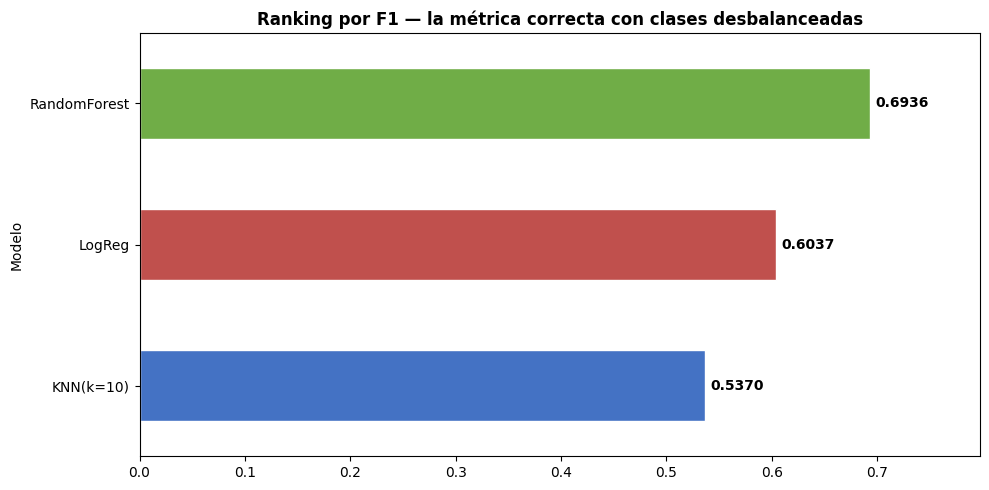


🏆 GANADOR según F1: RandomForest con F1 = 0.6936


In [58]:
# Barplot del F1 (la métrica clave)
fig, ax = plt.subplots(figsize=(10, 5))
colores = ['#4472C4', '#C0504D', '#70AD47', '#ED7D31']
tabla['F1'].sort_values().plot(kind='barh', color=colores, edgecolor='white', ax=ax)
for i, v in enumerate(tabla['F1'].sort_values()):
    ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontweight='bold')
ax.set_title('Ranking por F1 — la métrica correcta con clases desbalanceadas', fontweight='bold')
ax.set_xlim(0, max(tabla['F1']) * 1.15)
plt.tight_layout(); plt.show()

ganador = tabla['F1'].idxmax()
print(f'\n🏆 GANADOR según F1: {ganador} con F1 = {tabla.loc[ganador, "F1"]:.4f}')

In [59]:
# Creo las 3 matrices de confusión
for nombre, m in modelos.items():
    y_pred_model = m.predict(X_test)
    conf_matrix = confusion_matrix(y_test, y_pred_model)
    print(f'Matriz de Confusión para {nombre}:')
    print(conf_matrix)
    print('\n')

Matriz de Confusión para KNN(k=10):
[[ 0  0  0  1  0  0]
 [ 0  0  5  2  0  0]
 [ 0  0 74 22  1  0]
 [ 0  0 39 47  6  0]
 [ 0  0 12  9  8  0]
 [ 0  0  1  1  1  0]]


Matriz de Confusión para RandomForest:
[[ 0  0  1  0  0  0]
 [ 0  0  4  3  0  0]
 [ 0  0 83 13  1  0]
 [ 0  0 21 67  4  0]
 [ 0  0  3 12 14  0]
 [ 0  0  0  2  1  0]]


Matriz de Confusión para LogReg:
[[ 0  0  1  0  0  0]
 [ 0  0  4  3  0  0]
 [ 0  0 76 19  2  0]
 [ 0  0 25 58  8  1]
 [ 0  0  2 18  9  0]
 [ 0  0  0  1  2  0]]




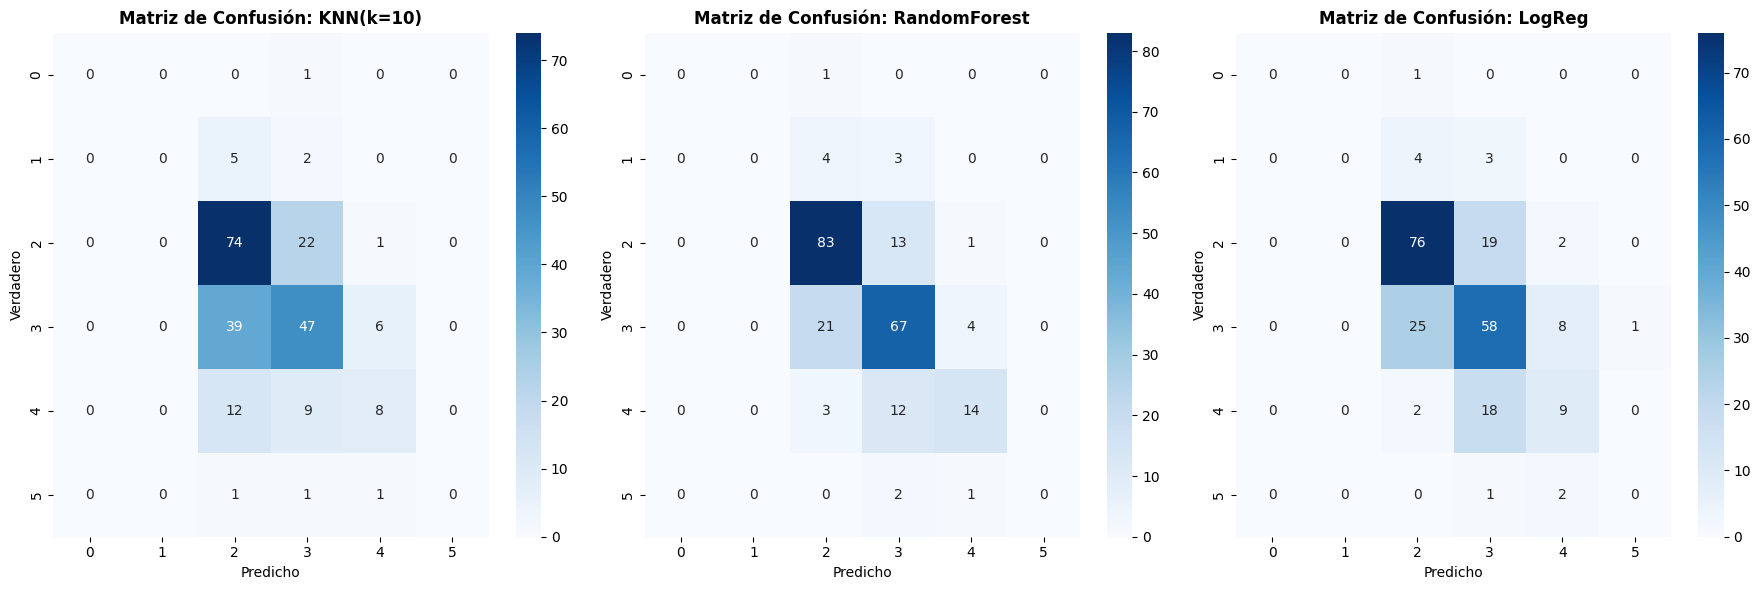

In [60]:
# para visualizar mejor las matrices de confusión se hace un subplot que incluye las 3.
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # 1 row, 3 columns
axes = axes.flatten() # Flatten the array for easy iteration

for i, (nombre, m) in enumerate(modelos.items()):
    y_pred_model = m.predict(X_test)
    conf_matrix = confusion_matrix(y_test, y_pred_model)

    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Matriz de Confusión: {nombre}', fontweight='bold')
    axes[i].set_xlabel('Predicho')
    axes[i].set_ylabel('Verdadero')

plt.tight_layout()
plt.show()

In [74]:
import numpy as np

def matrices(modelos, X_test, y_test):
    print("--- MATRICES DE CONFUSIÓN ---\n")

    for nombre, m in modelos.items():
        y_pred = m.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        total = np.sum(cm)
        aciertos = np.trace(cm)

        print(f"📌 Modelo: {nombre}")
        print(f"- Aciertos totales: {aciertos} de {total} muestras.")

        # Analizar clases mayoritarias (Calidad 5 y 6)
        # Las clases en el dataset suelen ser [3, 4, 5, 6, 7, 8]
        # El índice 2 es Calidad 5, el índice 3 es Calidad 6
        idx_5, idx_6 = 2, 3

        acierto_5 = cm[idx_5, idx_5] / np.sum(cm[idx_5, :]) if np.sum(cm[idx_5, :]) > 0 else 0
        acierto_6 = cm[idx_6, idx_6] / np.sum(cm[idx_6, :]) if np.sum(cm[idx_6, :]) > 0 else 0

        print(f"- Rendimiento en clase 5 (Promedio): {acierto_5:.1%}")
        print(f"- Rendimiento en clase 6 (Sobre el promedio): {acierto_6:.1%}")

        # Observación de errores comunes
        confundidos_5_con_6 = cm[idx_5, idx_6]
        confundidos_6_con_5 = cm[idx_6, idx_5]

        print(f"- Errores de bulto: Confundió {confundidos_5_con_6} vinos de calidad 5 con calidad 6.")

        if nombre == 'RandomForest':
            print("⭐ OBSERVACIÓN: Este modelo tiene la diagonal más marcada, indicando una mayor precisión general, especialmente en las clases centrales.")
        elif nombre == 'KNN(k=10)':
            print("⚠️ OBSERVACIÓN: Tiende a sesgarse mucho hacia las clases 5 y 6, ignorando casi por completo los extremos (calidad 3 u 8).")
        elif nombre == 'LogReg':
            print("ℹ️ OBSERVACIÓN: Muestra un comportamiento equilibrado pero con dificultades para distinguir entre calidades adyacentes (como 5 de 6).")
        print("-" * 30)

matrices(modelos, X_test, y_test)
# Codigo mejorado por IA

--- MATRICES DE CONFUSIÓN ---

📌 Modelo: KNN(k=10)
- Aciertos totales: 129 de 229 muestras.
- Rendimiento en clase 5 (Promedio): 76.3%
- Rendimiento en clase 6 (Sobre el promedio): 51.1%
- Errores de bulto: Confundió 22 vinos de calidad 5 con calidad 6.
⚠️ OBSERVACIÓN: Tiende a sesgarse mucho hacia las clases 5 y 6, ignorando casi por completo los extremos (calidad 3 u 8).
------------------------------
📌 Modelo: RandomForest
- Aciertos totales: 164 de 229 muestras.
- Rendimiento en clase 5 (Promedio): 85.6%
- Rendimiento en clase 6 (Sobre el promedio): 72.8%
- Errores de bulto: Confundió 13 vinos de calidad 5 con calidad 6.
⭐ OBSERVACIÓN: Este modelo tiene la diagonal más marcada, indicando una mayor precisión general, especialmente en las clases centrales.
------------------------------
📌 Modelo: LogReg
- Aciertos totales: 143 de 229 muestras.
- Rendimiento en clase 5 (Promedio): 78.4%
- Rendimiento en clase 6 (Sobre el promedio): 63.0%
- Errores de bulto: Confundió 19 vinos de calid

la Curva ROC no es muy visuala para clasificacion multicalse o no binaria

## 5.- Análisis y Comparación de Resultados:

* Comparar el rendimiento de los diferentes modelos.
* Discutir cuál modelo ofrece el mejor rendimiento y por qué.
* Identificar las fortalezas y debilidades de cada enfoque en este contexto.

In [71]:
# Uso el mismo codigo anterior que me mostro las metricas pero le agrego el tiempo de ejecución
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

filas2 = []
clases_unicas = sorted(y.unique())

for nombre, m2 in modelos.items():
    # Medir tiempo de inicio
    start_time = time.time()

    # Entrenar y predecir
    m2.fit(X_train, y_train)
    pred2 = modelo.predict(X_test)
    proba2 = modelo.predict_proba(X_test)

    # Medir tiempo de fin
    end_time = time.time()
    tiempo_ejecucion = end_time - start_time

    # Calcular métricas
    filas2.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, pred2),
        'Precision (Weighted)': precision_score(y_test, pred2, average='weighted', zero_division=0),
        'Recall (Weighted)': recall_score(y_test, pred2, average='weighted'),
        'F1-Score (Weighted)': f1_score(y_test, pred2, average='weighted'),
        'AUC-ROC': roc_auc_score(y_test, proba2, multi_class='ovr', average='weighted', labels=clases_unicas),
        'Tiempo Ejecución (s)': tiempo_ejecucion
    })

# Crear DataFrame comparativo
tabla2 = pd.DataFrame(filas2).set_index('Modelo')

# Mostrar la tabla formateada
print("Tabla Comparativa de Rendimiento y Tiempos:")
display(df_comparativo.sort_values(by='F1-Score (Weighted)', ascending=False).round(4))

Tabla Comparativa de Rendimiento y Tiempos:


,Accuracy,Precision (Weighted),Recall (Weighted),F1-Score (Weighted),AUC-ROC,Tiempo Ejecución (s)
Modelo,,,,,,
RandomForest,0.7162,0.6800,0.7162,0.6936,0.8518,0.8864
LogReg,0.6245,0.5877,0.6245,0.6037,0.7882,0.0525
KNN(k=10),0.5633,0.5329,0.5633,0.5370,0.6951,0.0331


In [72]:
# Resumen ejecutivo del rendimiento
mejor_f1 = df_comparativo['F1-Score (Weighted)'].max()
modelo_ganador = df_comparativo['F1-Score (Weighted)'].idxmax()
modelo_mas_rapido = df_comparativo['Tiempo Ejecución (s)'].idxmin()

print(f"--- CONCLUSIONES DE RENDIMIENTO ---")
print(f"1. Modelo con mejor equilibrio (F1): {modelo_ganador} ({mejor_f1:.4f})")
print(f"2. Modelo más eficiente en tiempo: {modelo_mas_rapido} ({df_comparativo.loc[modelo_mas_rapido, 'Tiempo Ejecución (s)']:.4f}s)")
print(f"3. El modelo {modelo_ganador} es el más robusto para predecir la calidad del vino basándose en las métricas ponderadas.")

--- CONCLUSIONES DE RENDIMIENTO ---
1. Modelo con mejor equilibrio (F1): RandomForest (0.6936)
2. Modelo más eficiente en tiempo: KNN(k=10) (0.0331s)
3. El modelo RandomForest es el más robusto para predecir la calidad del vino basándose en las métricas ponderadas.


### Análisis de Rendimiento y Métricas

Para entender qué modelo es mejor, no nos sirve solo la **Exactitud (Accuracy)**, sino también métricas que consideran el desbalance de las clases (ya que hay muchos más vinos de calidad '5' o '6' que '3' u '8'):

1.  **Accuracy**: Porcentaje total de aciertos. Es engañoso si las clases están desbalanceadas.
2.  **Precision**: Mide la calidad de las predicciones positivas (¿Qué tan seguro es el modelo cuando dice que un vino es de calidad 7?).
3.  **Recall**: Mide la capacidad de encontrar todos los casos positivos (¿Cuántos de los vinos excelentes realmente detectó?).
4.  **F1-Score**: El equilibrio (media armónica) entre Precision y Recall. Es la métrica más robusta aquí.
5.  **AUC-ROC**: Capacidad del modelo para distinguir entre clases. Un valor cercano a 1 es ideal.
6.  **Tiempo de Ejecución**: Crucial si planeamos usar el modelo en tiempo real o con millones de datos.

## 6.- Repositorio en GitHub:

* Crear un repositorio en GitHub con el código y los resultados del análisis.
* Crear un tag de liberación con una breve descripción de la versión final del proyecto.